# Contextual Embeddings Comparison (PhoBERT v2)

**Workflow**: Train (loose text) / Val → PhoBERT v2 (Pretrained & Finetuned) → Extract [CLS] from Layer 0 & Layer 12 → LogReg → Compare

**Strategy**:
1. Load train/val sets using **text_loose** (preprocessed but less aggressive than text_strict)
2. Extract embeddings from TWO layers:
   - **Layer 0 (Embedding layer)**: Token embeddings without encoder
   - **Layer 12 (Encoder output)**: [CLS] token after 12 encoder layers
3. Extract from both:
   - **PhoBERT v2** Pretrained (vinai/phobert-base-v2)
   - **PhoBERT v2** Finetuned (model/finetuned/PhoBERT_v2)
4. Train LogReg classifier on all 4 variants, evaluate on val_set
5. Compare metrics to see Layer 0 vs Layer 12 difference

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
import os
warnings.filterwarnings('ignore')

import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# GPU setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print("✅ Libraries imported successfully")

Device: cuda
✅ Libraries imported successfully


## 2. Load Data (Train/Val/Test)

In [2]:
# Load train, validation, and test sets
train_path = '../../data/splited/train_set.csv'
val_path = '../../data/splited/val_set.csv'

df_train = pd.read_csv(train_path)
df_val = pd.read_csv(val_path)

print("="*80)
print("DATA LOADED")
print("="*80)
print(f"\nTrain set: {df_train.shape[0]} rows × {df_train.shape[1]} columns")
print(f"  Label 0 (Fake): {(df_train['label'] == 0).sum()}")
print(f"  Label 1 (Real): {(df_train['label'] == 1).sum()}")

print(f"\nVal set: {df_val.shape[0]} rows × {df_val.shape[1]} columns")
print(f"  Label 0 (Fake): {(df_val['label'] == 0).sum()}")
print(f"  Label 1 (Real): {(df_val['label'] == 1).sum()}")

# Extract texts and labels (using text_loose for training)
texts_train = df_train['text_loose'].fillna('').tolist()
labels_train = df_train['label'].values

texts_val = df_val['text_loose'].fillna('').tolist()
labels_val = df_val['label'].values

print(f"\n✅ Text column loaded: text_loose")

DATA LOADED

Train set: 3788 rows × 28 columns
  Label 0 (Fake): 3143
  Label 1 (Real): 645

Val set: 474 rows × 28 columns
  Label 0 (Fake): 393
  Label 1 (Real): 81

✅ Text column loaded: text_loose


## 3. Utility Functions

In [3]:
def extract_embeddings(texts, model, tokenizer, device, batch_size=32, max_length=256):
    """
    Extract [CLS] token embeddings from BOTH Layer 0 (embedding) and Layer 12 (encoder output) of PhoBERT v2.
    Returns: (embeddings_layer0, embeddings_layer12) each with shape (num_texts, 768)
    """
    embeddings_layer0 = []
    embeddings_layer12 = []
    
    model.eval()
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size), desc="Extracting embeddings"):
            batch_texts = texts[i:i+batch_size]
            
            # Tokenize
            encoded = tokenizer(
                batch_texts,
                max_length=max_length,
                padding=True,
                truncation=True,
                return_tensors='pt'
            )
            
            # Move to device
            input_ids = encoded['input_ids'].to(device)
            attention_mask = encoded['attention_mask'].to(device)
            
            # Get model output with hidden states (all layers)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, output_hidden_states=True)
            
            # Extract [CLS] token from Layer 0 (embedding layer, first token)
            cls_layer0 = outputs.hidden_states[0][:, 0, :].cpu().numpy()
            embeddings_layer0.append(cls_layer0)
            
            # Extract [CLS] token from Layer 12 (encoder output, first token)
            cls_layer12 = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings_layer12.append(cls_layer12)
    
    # Concatenate all batches
    embeddings_layer0 = np.concatenate(embeddings_layer0, axis=0)
    embeddings_layer12 = np.concatenate(embeddings_layer12, axis=0)
    
    return embeddings_layer0, embeddings_layer12

def evaluate_embeddings(X_train, y_train, X_val, y_val, method_name):
    """
    Train LogReg on embeddings and evaluate on validation set.
    """
    # Scale embeddings
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    
    # Train LogReg
    clf = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    clf.fit(X_train_scaled, y_train)
    
    # Predict on validation
    y_pred = clf.predict(X_val_scaled)
    y_pred_proba = clf.predict_proba(X_val_scaled)[:, 1]
    
    results = {
        'method': method_name,
        'accuracy': accuracy_score(y_val, y_pred),
        'precision': precision_score(y_val, y_pred, average='weighted'),
        'recall': recall_score(y_val, y_pred, average='weighted'),
        'f1': f1_score(y_val, y_pred, average='weighted'),
        'auc': roc_auc_score(y_val, y_pred_proba)
    }
    
    return results

print("✅ Utility functions defined")

✅ Utility functions defined


## 4. Load PhoBERT v2 Pretrained

In [4]:
print("="*80)
print("PHOBERT V2 PRETRAINED")
print("="*80)
print("\nLoading PhoBERT v2 pretrained model...\n")

model_name = "vinai/phobert-base-v2"
tokenizer_pretrained = AutoTokenizer.from_pretrained(model_name)
model_pretrained = AutoModel.from_pretrained(model_name).to(device)

print(f"✓ Loaded {model_name}")
print(f"  Vocab size: {len(tokenizer_pretrained)}")
print(f"  Hidden size: 768")
print(f"  Device: {device}")

# Extract embeddings for train and val (BOTH Layer 0 and Layer 12)
print("\nExtracting embeddings (Train set)...")
X_train_layer0_pretrain, X_train_layer12_pretrain = extract_embeddings(texts_train, model_pretrained, tokenizer_pretrained, device)

print("\nExtracting embeddings (Val set)...")
X_val_layer0_pretrain, X_val_layer12_pretrain = extract_embeddings(texts_val, model_pretrained, tokenizer_pretrained, device)

print(f"\nEmbedding shapes:")
print(f"  Layer 0 (Embedding) - Train: {X_train_layer0_pretrain.shape}, Val: {X_val_layer0_pretrain.shape}")
print(f"  Layer 12 (Encoder) - Train: {X_train_layer12_pretrain.shape}, Val: {X_val_layer12_pretrain.shape}")

# Evaluate both layers
results_pretrain_layer0 = evaluate_embeddings(X_train_layer0_pretrain, labels_train, X_val_layer0_pretrain, labels_val, "PhoBERT v2 Pretrained (Layer 0)")
results_pretrain_layer12 = evaluate_embeddings(X_train_layer12_pretrain, labels_train, X_val_layer12_pretrain, labels_val, "PhoBERT v2 Pretrained (Layer 12)")

print(f"\n✅ PhoBERT v2 Pretrained Results:")
print(f"\n  Layer 0 (Embedding):")
for k, v in results_pretrain_layer0.items():
    if k != 'method':
        print(f"    {k}: {v:.4f}")

print(f"\n  Layer 12 (Encoder Output):")
for k, v in results_pretrain_layer12.items():
    if k != 'method':
        print(f"    {k}: {v:.4f}")

PHOBERT V2 PRETRAINED

Loading PhoBERT v2 pretrained model...



Some weights of RobertaModel were not initialized from the model checkpoint at vinai/phobert-base-v2 and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Loaded vinai/phobert-base-v2
  Vocab size: 64001
  Hidden size: 768
  Device: cuda

Extracting embeddings (Train set)...


Extracting embeddings: 100%|██████████| 119/119 [01:31<00:00,  1.29it/s]



Extracting embeddings (Val set)...


Extracting embeddings: 100%|██████████| 15/15 [00:12<00:00,  1.21it/s]



Embedding shapes:
  Layer 0 (Embedding) - Train: (3788, 768), Val: (474, 768)
  Layer 12 (Encoder) - Train: (3788, 768), Val: (474, 768)

✅ PhoBERT v2 Pretrained Results:

  Layer 0 (Embedding):
    accuracy: 0.8291
    precision: 0.6874
    recall: 0.8291
    f1: 0.7517
    auc: 0.5000

  Layer 12 (Encoder Output):
    accuracy: 0.8586
    precision: 0.8733
    recall: 0.8586
    f1: 0.8643
    auc: 0.8975


In [5]:
print("\n" + "="*80)
print("PHOBERT V2 ARCHITECTURE - ALL LAYERS")
print("="*80)
print(f"\n{model_pretrained}")
print("\n" + "="*80)
print("LAYER SUMMARY")
print("="*80)
print(f"\nTotal layers: {len(list(model_pretrained.children()))}")
for i, layer in enumerate(model_pretrained.children()):
    print(f"Layer {i}: {layer.__class__.__name__}")

print("\n" + "="*80)
print("ENCODER LAYERS (HIDDEN STATES)")
print("="*80)
print("PhoBERT has 13 hidden states:")
print("  - hidden_states[0]: Embedding layer output (768-dim)")
print("  - hidden_states[1-12]: Output of encoder layers 1-12 (each 768-dim)")
print(f"\nSo when extracting embeddings:")
print(f"  - Layer 0 = hidden_states[0] (embedding layer - WEAK)")
print(f"  - Layer 12 = hidden_states[12] = last_hidden_state (encoder output - STRONG)")


PHOBERT V2 ARCHITECTURE - ALL LAYERS

RobertaModel(
  (embeddings): RobertaEmbeddings(
    (word_embeddings): Embedding(64001, 768, padding_idx=1)
    (position_embeddings): Embedding(258, 768, padding_idx=1)
    (token_type_embeddings): Embedding(1, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): RobertaEncoder(
    (layer): ModuleList(
      (0-11): 12 x RobertaLayer(
        (attention): RobertaAttention(
          (self): RobertaSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): RobertaSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-05, e

## 5. Load PhoBERT v2 Finetuned

In [6]:
print("="*80)
print("PHOBERT V2 FINETUNED")
print("="*80)
print("\nLoading PhoBERT v2 finetuned model...\n")

finetuned_model_path = "../../model/finetuned/PhoBERT_v2"

try:
    tokenizer_finetuned = AutoTokenizer.from_pretrained(finetuned_model_path)
    model_finetuned = AutoModel.from_pretrained(finetuned_model_path).to(device)
    
    print(f"✓ Loaded finetuned model from {finetuned_model_path}")
    print(f"  Vocab size: {len(tokenizer_finetuned)}")
    print(f"  Hidden size: 768")
    print(f"  Device: {device}")
    
    # Extract embeddings for train and val (BOTH Layer 0 and Layer 12)
    print("\nExtracting embeddings (Train set)...")
    X_train_layer0_finetuned, X_train_layer12_finetuned = extract_embeddings(texts_train, model_finetuned, tokenizer_finetuned, device)
    
    print("\nExtracting embeddings (Val set)...")
    X_val_layer0_finetuned, X_val_layer12_finetuned = extract_embeddings(texts_val, model_finetuned, tokenizer_finetuned, device)
    
    print(f"\nEmbedding shapes:")
    print(f"  Layer 0 (Embedding) - Train: {X_train_layer0_finetuned.shape}, Val: {X_val_layer0_finetuned.shape}")
    print(f"  Layer 12 (Encoder) - Train: {X_train_layer12_finetuned.shape}, Val: {X_val_layer12_finetuned.shape}")
    
    # Evaluate both layers
    results_finetuned_layer0 = evaluate_embeddings(X_train_layer0_finetuned, labels_train, X_val_layer0_finetuned, labels_val, "PhoBERT v2 Finetuned (Layer 0)")
    results_finetuned_layer12 = evaluate_embeddings(X_train_layer12_finetuned, labels_train, X_val_layer12_finetuned, labels_val, "PhoBERT v2 Finetuned (Layer 12)")
    
    print(f"\n✅ PhoBERT v2 Finetuned Results:")
    print(f"\n  Layer 0 (Embedding):")
    for k, v in results_finetuned_layer0.items():
        if k != 'method':
            print(f"    {k}: {v:.4f}")
    
    print(f"\n  Layer 12 (Encoder Output):")
    for k, v in results_finetuned_layer12.items():
        if k != 'method':
            print(f"    {k}: {v:.4f}")
            
except Exception as e:
    print(f"⚠️ Error loading finetuned model: {e}")
    print("Make sure n1_phobert_v2.ipynb has been run successfully.")
    results_finetuned_layer0 = None
    results_finetuned_layer12 = None

Some weights of RobertaModel were not initialized from the model checkpoint at ../../model/finetuned/PhoBERT_v2 and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


PHOBERT V2 FINETUNED

Loading PhoBERT v2 finetuned model...

✓ Loaded finetuned model from ../../model/finetuned/PhoBERT_v2
  Vocab size: 64001
  Hidden size: 768
  Device: cuda

Extracting embeddings (Train set)...


Extracting embeddings: 100%|██████████| 119/119 [01:36<00:00,  1.23it/s]



Extracting embeddings (Val set)...


Extracting embeddings: 100%|██████████| 15/15 [00:12<00:00,  1.20it/s]



Embedding shapes:
  Layer 0 (Embedding) - Train: (3788, 768), Val: (474, 768)
  Layer 12 (Encoder) - Train: (3788, 768), Val: (474, 768)

✅ PhoBERT v2 Finetuned Results:

  Layer 0 (Embedding):
    accuracy: 0.8291
    precision: 0.6874
    recall: 0.8291
    f1: 0.7517
    auc: 0.5000

  Layer 12 (Encoder Output):
    accuracy: 0.8966
    precision: 0.8961
    recall: 0.8966
    f1: 0.8964
    auc: 0.8622


## 6. Compare Results

In [7]:
print("\n" + "="*80)
print("COMPREHENSIVE RESULTS TABLE: ALL 4 COMBINATIONS")
print("="*80)

# Create results dataframe with explicit naming
results_data = []

# Pretrained Layer 0
results_data.append({
    'Model': 'PhoBERT v2 Pretrained',
    'Layer': 'Layer 0 (Embedding)',
    'Accuracy': results_pretrain_layer0['accuracy'],
    'Precision': results_pretrain_layer0['precision'],
    'Recall': results_pretrain_layer0['recall'],
    'F1': results_pretrain_layer0['f1'],
    'AUC-ROC': results_pretrain_layer0['auc']
})

# Pretrained Layer 12
results_data.append({
    'Model': 'PhoBERT v2 Pretrained',
    'Layer': 'Layer 12 (Encoder)',
    'Accuracy': results_pretrain_layer12['accuracy'],
    'Precision': results_pretrain_layer12['precision'],
    'Recall': results_pretrain_layer12['recall'],
    'F1': results_pretrain_layer12['f1'],
    'AUC-ROC': results_pretrain_layer12['auc']
})

# Finetuned Layer 0
results_data.append({
    'Model': 'PhoBERT v2 Finetuned',
    'Layer': 'Layer 0 (Embedding)',
    'Accuracy': results_finetuned_layer0['accuracy'],
    'Precision': results_finetuned_layer0['precision'],
    'Recall': results_finetuned_layer0['recall'],
    'F1': results_finetuned_layer0['f1'],
    'AUC-ROC': results_finetuned_layer0['auc']
})

# Finetuned Layer 12
results_data.append({
    'Model': 'PhoBERT v2 Finetuned',
    'Layer': 'Layer 12 (Encoder)',
    'Accuracy': results_finetuned_layer12['accuracy'],
    'Precision': results_finetuned_layer12['precision'],
    'Recall': results_finetuned_layer12['recall'],
    'F1': results_finetuned_layer12['f1'],
    'AUC-ROC': results_finetuned_layer12['auc']
})

df_results = pd.DataFrame(results_data)

# Display results table
print("\n" + df_results.to_string(index=False))

# Also display with more decimal places for better precision
print("\n" + "="*80)
print("DETAILED RESULTS (4 decimal places)")
print("="*80)
print(df_results.round(4).to_string(index=False))

print("\n" + "="*80)
print("KEY INSIGHTS")
print("="*80)

# Compare Layer 0 vs Layer 12 for Pretrained
f1_layer0_pretrain = results_pretrain_layer0['f1']
f1_layer12_pretrain = results_pretrain_layer12['f1']
diff_pretrain = f1_layer12_pretrain - f1_layer0_pretrain

print(f"\n🔍 Pretrained:")
print(f"  Layer 0 (Embedding):    F1={f1_layer0_pretrain:.4f}")
print(f"  Layer 12 (Encoder):     F1={f1_layer12_pretrain:.4f}")
print(f"  Difference (Layer12-Layer0): {diff_pretrain:+.4f} {'↑ (Layer 12 better!)' if diff_pretrain > 0 else '↓ (Layer 0 better!)'}")

# Compare Layer 0 vs Layer 12 for Finetuned
f1_layer0_finetuned = results_finetuned_layer0['f1']
f1_layer12_finetuned = results_finetuned_layer12['f1']
diff_finetuned = f1_layer12_finetuned - f1_layer0_finetuned

print(f"\n🔍 Finetuned:")
print(f"  Layer 0 (Embedding):    F1={f1_layer0_finetuned:.4f}")
print(f"  Layer 12 (Encoder):     F1={f1_layer12_finetuned:.4f}")
print(f"  Difference (Layer12-Layer0): {diff_finetuned:+.4f} {'↑ (Layer 12 better!)' if diff_finetuned > 0 else '↓ (Layer 0 better!)'}")

# Compare Pretrained vs Finetuned at Layer 12
diff_pretrain_vs_finetuned = f1_layer12_finetuned - f1_layer12_pretrain
print(f"\n🔍 Layer 12 Comparison:")
print(f"  Pretrained: F1={f1_layer12_pretrain:.4f}")
print(f"  Finetuned:  F1={f1_layer12_finetuned:.4f}")
print(f"  Difference (Finetuned-Pretrained): {diff_pretrain_vs_finetuned:+.4f} {'↑ (Finetuned better!)' if diff_pretrain_vs_finetuned > 0 else '↓ (Pretrained better!)'}")


COMPREHENSIVE RESULTS TABLE: ALL 4 COMBINATIONS

                Model               Layer  Accuracy  Precision   Recall       F1  AUC-ROC
PhoBERT v2 Pretrained Layer 0 (Embedding)  0.829114   0.687430 0.829114 0.751653 0.500000
PhoBERT v2 Pretrained  Layer 12 (Encoder)  0.858650   0.873314 0.858650 0.864318 0.897496
 PhoBERT v2 Finetuned Layer 0 (Embedding)  0.829114   0.687430 0.829114 0.751653 0.500000
 PhoBERT v2 Finetuned  Layer 12 (Encoder)  0.896624   0.896125 0.896624 0.896369 0.862218

DETAILED RESULTS (4 decimal places)
                Model               Layer  Accuracy  Precision  Recall     F1  AUC-ROC
PhoBERT v2 Pretrained Layer 0 (Embedding)    0.8291     0.6874  0.8291 0.7517   0.5000
PhoBERT v2 Pretrained  Layer 12 (Encoder)    0.8586     0.8733  0.8586 0.8643   0.8975
 PhoBERT v2 Finetuned Layer 0 (Embedding)    0.8291     0.6874  0.8291 0.7517   0.5000
 PhoBERT v2 Finetuned  Layer 12 (Encoder)    0.8966     0.8961  0.8966 0.8964   0.8622

KEY INSIGHTS

🔍 Pretrained:


VISUALIZATION: LAYER 0 VS LAYER 12


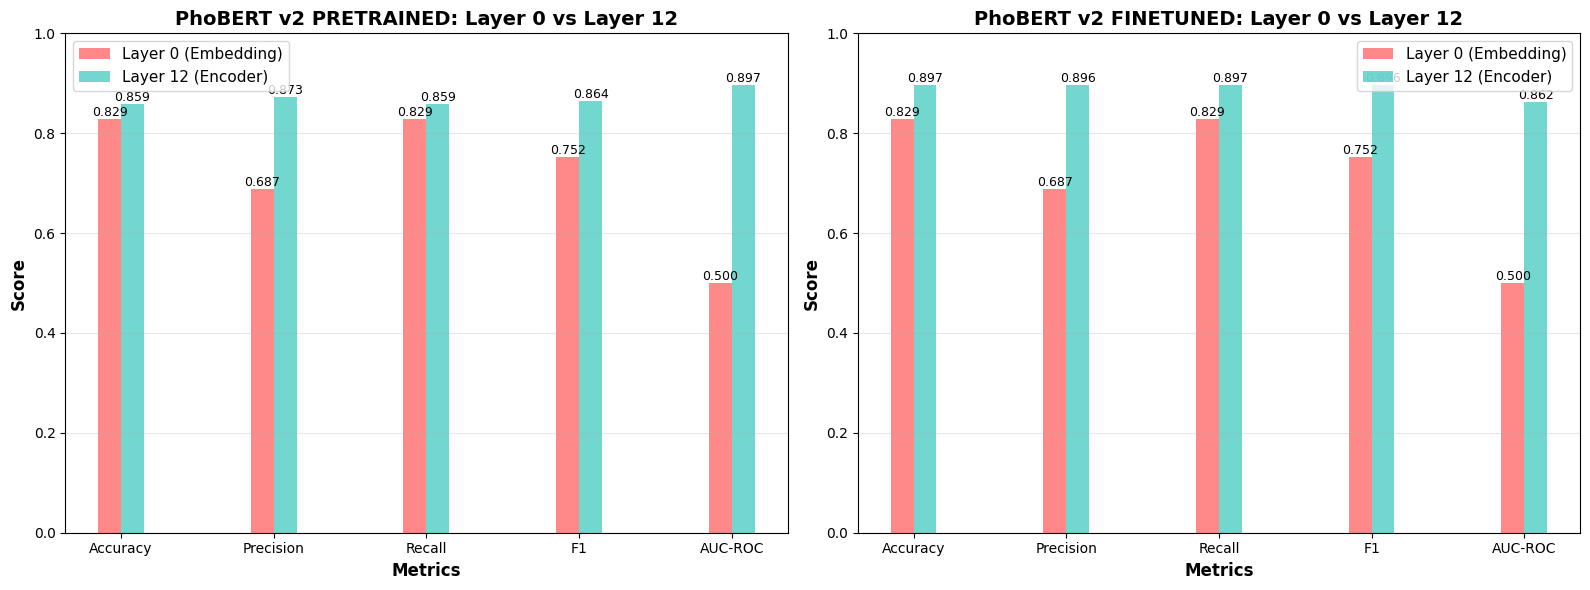

In [10]:
print("\n" + "="*80)
print("VISUALIZATION: LAYER 0 VS LAYER 12")
print("="*80)

import matplotlib.pyplot as plt
import numpy as np

# Prepare data for visualization
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC']
x = np.arange(len(metrics))
width = 0.15

# Create figure with multiple subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ========== PRETRAINED COMPARISON ==========
ax = axes[0]
values_layer0 = [results_pretrain_layer0['accuracy'], results_pretrain_layer0['precision'], 
                 results_pretrain_layer0['recall'], results_pretrain_layer0['f1'], 
                 results_pretrain_layer0['auc']]
values_layer12 = [results_pretrain_layer12['accuracy'], results_pretrain_layer12['precision'], 
                  results_pretrain_layer12['recall'], results_pretrain_layer12['f1'], 
                  results_pretrain_layer12['auc']]

bars1 = ax.bar(x - width/2, values_layer0, width, label='Layer 0 (Embedding)', color='#FF6B6B', alpha=0.8)
bars2 = ax.bar(x + width/2, values_layer12, width, label='Layer 12 (Encoder)', color='#4ECDC4', alpha=0.8)

ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('PhoBERT v2 PRETRAINED: Layer 0 vs Layer 12', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim([0, 1.0])
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

# ========== FINETUNED COMPARISON ==========
ax = axes[1]
values_layer0_ft = [results_finetuned_layer0['accuracy'], results_finetuned_layer0['precision'], 
                    results_finetuned_layer0['recall'], results_finetuned_layer0['f1'], 
                    results_finetuned_layer0['auc']]
values_layer12_ft = [results_finetuned_layer12['accuracy'], results_finetuned_layer12['precision'], 
                     results_finetuned_layer12['recall'], results_finetuned_layer12['f1'], 
                     results_finetuned_layer12['auc']]

bars3 = ax.bar(x - width/2, values_layer0_ft, width, label='Layer 0 (Embedding)', color='#FF6B6B', alpha=0.8)
bars4 = ax.bar(x + width/2, values_layer12_ft, width, label='Layer 12 (Encoder)', color='#4ECDC4', alpha=0.8)

ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('PhoBERT v2 FINETUNED: Layer 0 vs Layer 12', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim([0, 1.0])
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 7. Save Results & Embeddings

In [11]:
# Save results to CSV
output_dir = '../../data/encoded/contextual_embeddings'
os.makedirs(output_dir, exist_ok=True)

csv_path = f'{output_dir}/phobert_v2_comparison.csv'
df_results.to_csv(csv_path, index=False)

print("="*80)
print("RESULTS SAVED")
print("="*80)
print(f"\n✅ Results saved to: {csv_path}")
print(f"\nDetailed Results:")
print(df_results.to_string(index=False))

RESULTS SAVED

✅ Results saved to: ../../data/encoded/contextual_embeddings/phobert_v2_comparison.csv

Detailed Results:
                Model               Layer  Accuracy  Precision   Recall       F1  AUC-ROC
PhoBERT v2 Pretrained Layer 0 (Embedding)  0.829114   0.687430 0.829114 0.751653 0.500000
PhoBERT v2 Pretrained  Layer 12 (Encoder)  0.858650   0.873314 0.858650 0.864318 0.897496
 PhoBERT v2 Finetuned Layer 0 (Embedding)  0.829114   0.687430 0.829114 0.751653 0.500000
 PhoBERT v2 Finetuned  Layer 12 (Encoder)  0.896624   0.896125 0.896624 0.896369 0.862218
